In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install itables
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

In [117]:
file_id = '1UWJG-uYpqVdLSbrKfmu5olvYkETAuwbo'

url_drive = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_excel(url_drive, sheet_name='Base_Datos',engine='openpyxl')

show(df.head(5))
#df.tail(5)
print(df.columns)

Loading ITables v2.8.0 from the internet... (need help?)


Index(['Fecha', 'Año', 'Mes_Num', 'Mes', 'Trimestre', 'Centro_Cultivo',
       'Comuna', 'Zona', 'Tipo_Producto', 'Mercado', 'Destino_Venta',
       'Ton_Producidas', 'Ton_Vendidas', 'Precio_Ton_CLP',
       'Costo_Unitario_CLP', 'Rechazos_Calidad', 'Mortalidad_%',
       'Ingresos_CLP', 'Costo_Produccion_CLP', 'Margen_CLP', 'Margen_%',
       'Costo_por_Tonelada', 'Cumplimiento_Venta_%',
       'Produccion_Neta_Estimada', 'Ton_No_Vendidas', 'Nivel_Mortalidad',
       'Nivel_Rentabilidad', 'Estado_Operacion', 'Alerta_Dashboard',
       'Orden_Mes', 'Codigo_Centro', 'Tasa_Rechazo_x_Ton',
       'Ingreso_por_Ton_Vendida', 'Margen_por_Ton_Vendida',
       'Ingreso_Exportacion_CLP', 'Flag_Critico', 'Foco_Storytelling',
       'Mes_Etiqueta', 'Centro_Orden', 'Zona_Mercado', 'Producto_Mercado',
       'Ranking_Margen_%', 'Flag_Exportacion', 'Flag_Alerta_Critico'],
      dtype='object')


In [40]:
#Descripción de variables
info_df = pd.read_excel("/content/drive/MyDrive/Centros y registros.xlsx", sheet_name='Diccionario_Datos')
show(info_df)

Loading ITables v2.8.0 from the internet... (need help?)


Análisi exploratorio de datos


In [41]:
print("Resumen descriptivo de variables numéricas")
print(df.describe())
print(df.dtypes)

Resumen descriptivo de variables numéricas
                     Fecha     Año     Mes_Num  Ton_Producidas  Ton_Vendidas  \
count                  240   240.0  240.000000      240.000000    240.000000   
mean   2025-06-16 12:00:00  2025.0    6.500000      119.299583    105.088750   
min    2025-01-01 00:00:00  2025.0    1.000000       61.600000     52.800000   
25%    2025-03-24 06:00:00  2025.0    3.750000       99.250000     86.400000   
50%    2025-06-16 00:00:00  2025.0    6.500000      115.300000    103.300000   
75%    2025-09-08 12:00:00  2025.0    9.250000      137.400000    121.325000   
max    2025-12-01 00:00:00  2025.0   12.000000      216.200000    212.200000   
std                    NaN     0.0    3.459267       28.538867     26.185917   

       Precio_Ton_CLP  Costo_Unitario_CLP  Rechazos_Calidad  Mortalidad_%  \
count    2.400000e+02          240.000000        240.000000    240.000000   
mean     1.044483e+06       517312.500000          3.791667      0.055717   
min  

In [42]:
def resumen_general(df: pd.DataFrame) -> pd.DataFrame:
    """
    Imprime shape, periodo (si hay columna de fecha) y devuelve una tabla
    con dtype, n° valores únicos y ejemplo de valor por columna.

    Retorna:
    DataFrame con columnas: dtype | n_unicos | ejemplo | es_categorica
    """
    print(f"Shape : {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

    # Detectar columnas de fecha para mostrar rango
    fecha_cols = df.select_dtypes(include=["datetime64"]).columns.tolist()
    if fecha_cols:
        for col in fecha_cols:
            print(f"Rango [{col}]: {df[col].min().date()} → {df[col].max().date()}")
        print()

    resumen = pd.DataFrame({
        "dtype":        df.dtypes.astype(str),
        "n_unicos":     df.nunique(),
        "n_nulos":      df.isnull().sum(),
        "pct_nulos":    (df.isnull().mean() * 100).round(1),
        "ejemplo":      df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else "—"),
        "es_numerica":  df.apply(lambda c: pd.api.types.is_numeric_dtype(c)),
    })
    return resumen

In [43]:
#Calidad de datos
resumen_general(df)

Shape : 240 filas × 44 columnas
Memoria: 0.3 MB

Rango [Fecha]: 2025-01-01 → 2025-12-01



Loading ITables v2.8.0 from the internet... (need help?)


In [44]:
cols = df.select_dtypes(include="number").columns.tolist()
df

Loading ITables v2.8.0 from the internet... (need help?)


In [45]:
df_numeric = df[cols]
df_numeric['Centro'] = df['Centro_Cultivo']
df_numeric.head()

/tmp/ipykernel_18431/2921428075.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric['Centro'] = df['Centro_Cultivo']


Loading ITables v2.8.0 from the internet... (need help?)


In [46]:
#Variables categóricas
cols_categoricas = df.select_dtypes(exclude=np.number).columns.tolist()
df_cat = df[cols_categoricas]
df_cat.head()

Loading ITables v2.8.0 from the internet... (need help?)


In [47]:
#Análisis cuantitativo
#Análisis por centro
#print(df_numeric.describe())
#print(df.groupby('Mercado')[['Ton_Vendidas','Costo_Produccion_CLP']].sum())
df['Ton_Merma'] = df['Ton_Producidas'] - df['Produccion_Neta_Estimada']
print("Resultados operacionales por centro")
show(df.pivot_table(index='Centro_Cultivo', values=['Ton_Producidas','Costo_Produccion_CLP','Ingreso_Exportacion_CLP'], aggfunc='sum'))
print('Nivel de monitoreo de Centros')
show(pd.crosstab(df.Centro_Cultivo,df.Alerta_Dashboard))
print("Destino de producción de centros")
show(pd.crosstab(df.Centro_Cultivo,df.Mercado))
print("Concentración por mortalidad de centros")
show(pd.crosstab(df.Centro_Cultivo,df.Nivel_Mortalidad))

Resultados operacionales por centro


Loading ITables v2.8.0 from the internet... (need help?)


Nivel de monitoreo de Centros


Loading ITables v2.8.0 from the internet... (need help?)


Destino de producción de centros


Loading ITables v2.8.0 from the internet... (need help?)


Concentración por mortalidad de centros


Loading ITables v2.8.0 from the internet... (need help?)


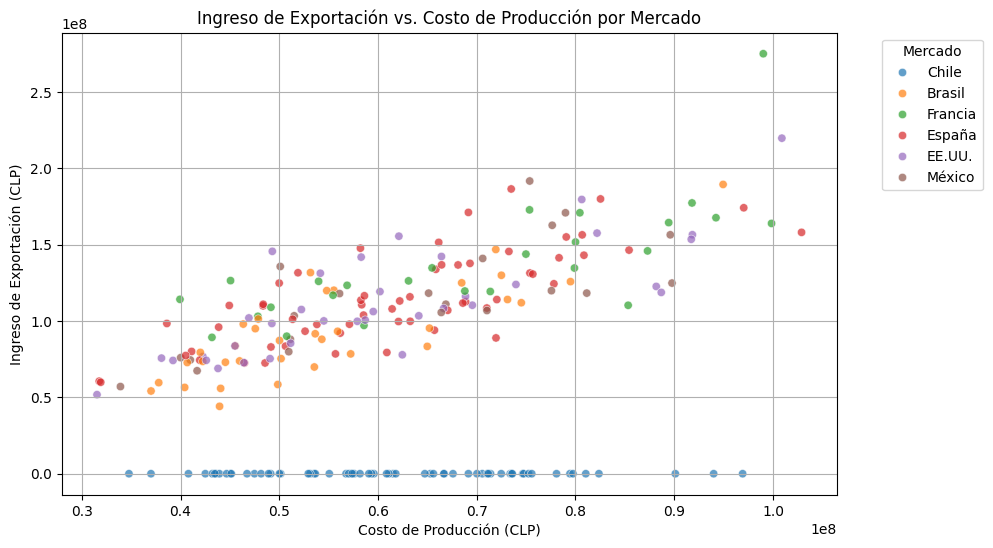

In [71]:
# Get unique 'Mercado' categories and their colors for consistent plotting and legend
hue_categories = df['Mercado'].unique()
palette = sns.color_palette('tab10', n_colors=len(hue_categories))
hue_colors = {cat: palette[j] for j, cat in enumerate(hue_categories)}

plt.figure(figsize=(10, 6))

sns.scatterplot(
        data=df,
        x='Costo_Produccion_CLP',
        y='Ingreso_Exportacion_CLP',
        hue='Mercado', # Add color based on 'Mercado'
        palette=hue_colors, # Use the defined palette for consistency
        alpha=0.7,
        edgecolor="w"
    )
plt.title('Ingreso de Exportación vs. Costo de Producción por Mercado')
plt.xlabel('Costo de Producción (CLP)')
plt.ylabel('Ingreso de Exportación (CLP)')
plt.legend(title='Mercado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [48]:
print("Desempeño Comercial")

# Define the currency formatting function
def format_currency(amount):
    if pd.isna(amount):
        return ""
    # Format as Chilean Pesos with thousands separator and 0 decimal places
    return f"CLP {amount:,.0f}"

df['Beneficio medio'] = df['Margen_CLP']/df['Ton_Producidas'].round(2)
show(df.pivot_table(index='Centro_Cultivo',
                    values=['Ingreso_Exportacion_CLP','Ton_Producidas','Costo_Produccion_CLP','Beneficio medio','Margen_CLP'],
                    aggfunc={'Ingreso_Exportacion_CLP': 'sum', 'Ton_Producidas': 'sum', 'Costo_Produccion_CLP': 'sum', 'Margen_CLP':'sum','Beneficio medio': 'mean'}).round(2))
print("Desempeño Comercial")
print("Destino de producción de centros")

# Calculate the crosstab for Ingresos_CLP
crosstab_ingresos_clp = pd.crosstab(df.Centro_Cultivo, df.Mercado, values=df['Ingresos_CLP'], aggfunc='sum')
crosstab_beneficio_absoluto = pd.crosstab(df.Centro_Cultivo,df.Mercado,values=df['Margen_CLP'], aggfunc='sum')
crosstab_beneficio_medio = pd.crosstab(df.Centro_Cultivo,df.Mercado,values=df['Beneficio medio'], aggfunc='mean')

# Apply the currency formatting function to the crosstab values directly
formatted_crosstab_ingresos_clp = crosstab_ingresos_clp.map(format_currency)
form_crosstab_beneficio_absoluto = crosstab_beneficio_absoluto.map(format_currency)
form_crosstab_beneficio_medio = crosstab_beneficio_medio.map(format_currency)

# Display the pre-formatted crosstab
show(formatted_crosstab_ingresos_clp)

# Display other crosstabs without specific formatting, as per user's last feedback
show(form_crosstab_beneficio_absoluto)
show(form_crosstab_beneficio_medio)

Desempeño Comercial


Loading ITables v2.8.0 from the internet... (need help?)


Desempeño Comercial
Destino de producción de centros


Loading ITables v2.8.0 from the internet... (need help?)


Loading ITables v2.8.0 from the internet... (need help?)


Loading ITables v2.8.0 from the internet... (need help?)


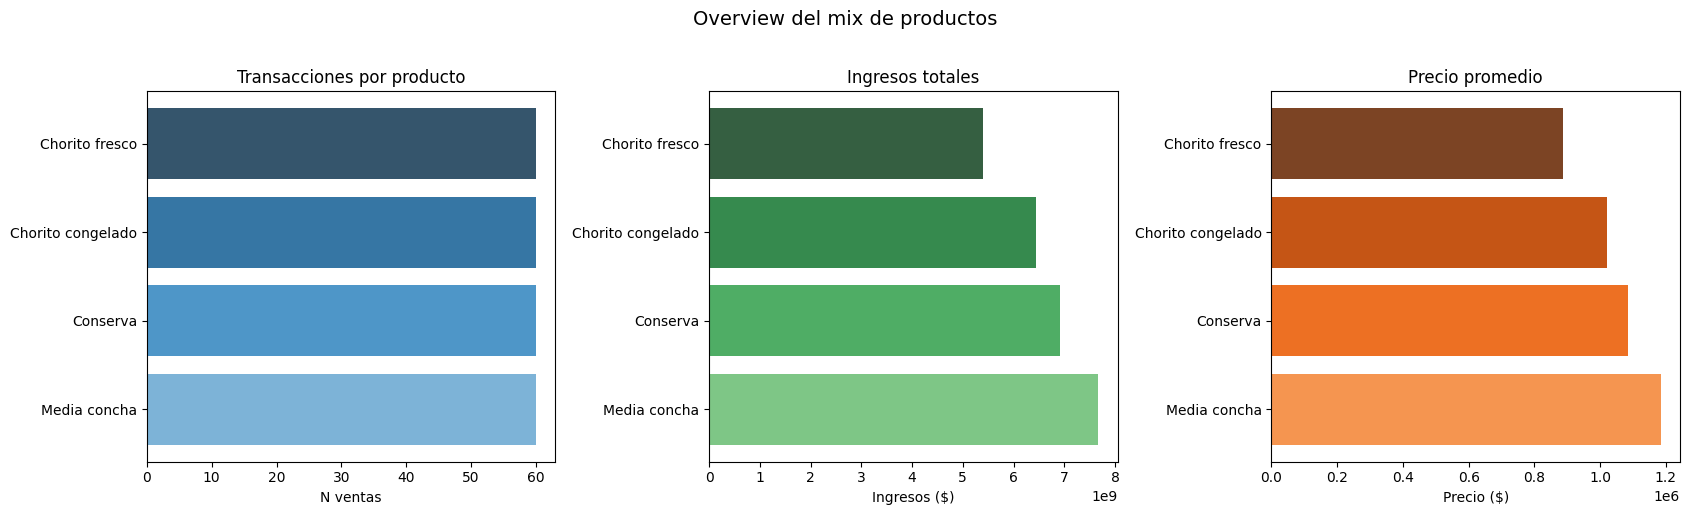

Loading ITables v2.8.0 from the internet... (need help?)


In [65]:
#Resumen por producto

product_stats = (
    df.groupby("Tipo_Producto")
      .agg(qty=("Ingresos_CLP","count"), revenue=("Ingresos_CLP","sum"), avg_price=("Precio_Ton_CLP","mean"))
      .sort_values("revenue", ascending=False)
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].barh(product_stats["Tipo_Producto"], product_stats["qty"],
             color=sns.color_palette("Blues_d", len(product_stats)))
axes[0].set_title("Transacciones por producto"); axes[0].set_xlabel("N ventas")

axes[1].barh(product_stats["Tipo_Producto"], product_stats["revenue"],
             color=sns.color_palette("Greens_d", len(product_stats)))
axes[1].set_title("Ingresos totales"); axes[1].set_xlabel("Ingresos ($)")

axes[2].barh(product_stats["Tipo_Producto"], product_stats["avg_price"],
             color=sns.color_palette("Oranges_d", len(product_stats)))
axes[2].set_title("Precio promedio"); axes[2].set_xlabel("Precio ($)")

plt.suptitle("Overview del mix de productos", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
display(product_stats.round(2))


## **Análisis de planificación de la producción**
Buscaremos brechas y fortalezas en la planificacion industrial de la empresa en pro de nivelar posibles riesgos y orientar desiciones en a oportunidades

Loading ITables v2.8.0 from the internet... (need help?)


Loading ITables v2.8.0 from the internet... (need help?)


Loading ITables v2.8.0 from the internet... (need help?)


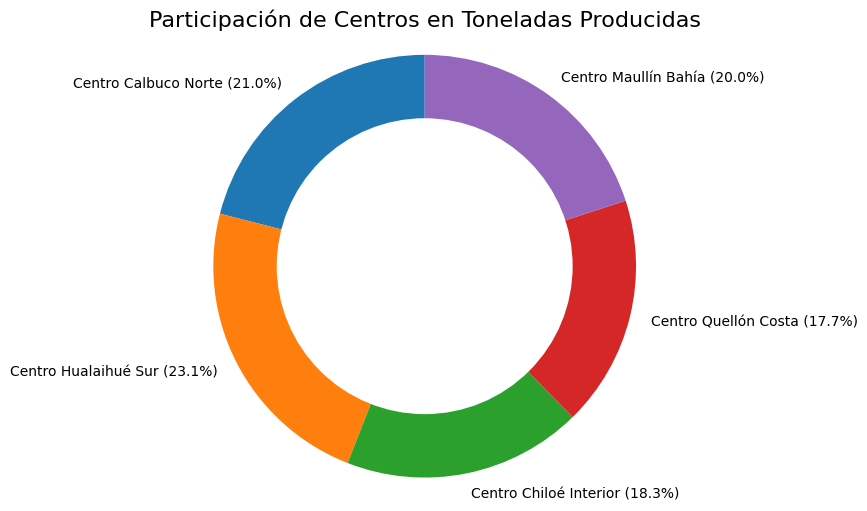

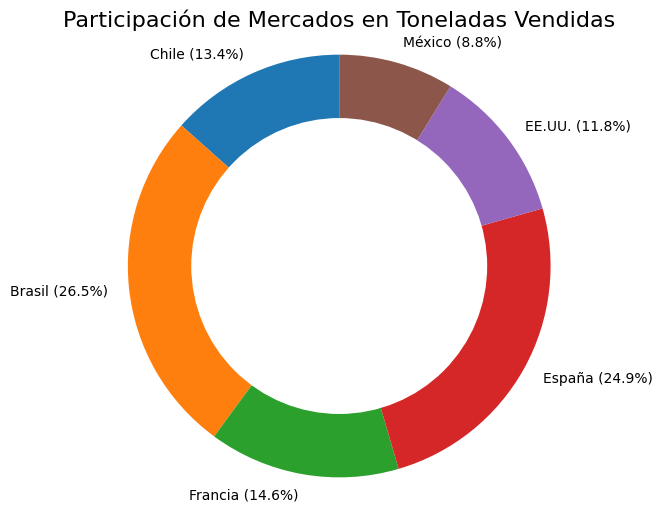

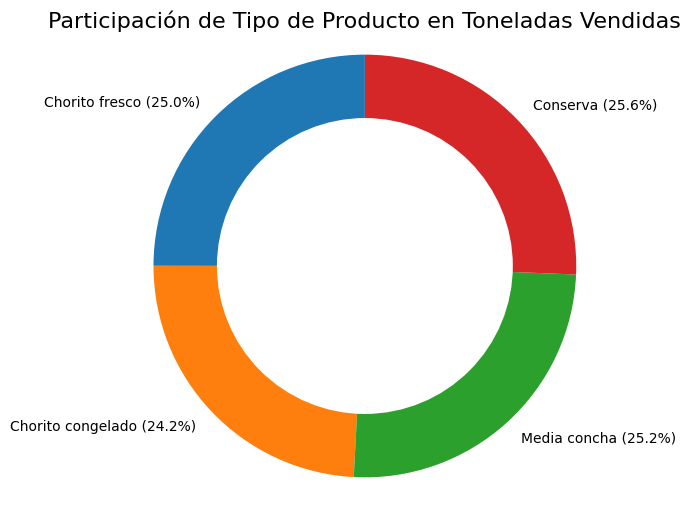

In [76]:
#Preparamos la data
participacion = pd.DataFrame({
    'Centros' : df['Centro_Cultivo'].unique(),
    'Participacion' : df.groupby('Centro_Cultivo')['Ton_Producidas'].sum()/df['Ton_Producidas'].sum(),
    'margen %' : df.groupby('Centro_Cultivo')['Margen_CLP'].sum()/df['Margen_CLP'].sum()}
)
# 'participacion['Participacion']' is the vector of participation for each center.
show(participacion.head(5))

exportaciones = pd.DataFrame({
    'Mercados' : df['Mercado'].unique(),
    'Participacion' : df.groupby('Mercado')['Ton_Vendidas'].sum()/df['Ton_Vendidas'].sum(),
    'margen %' : df.groupby('Mercado')['Margen_CLP'].sum()/df['Margen_CLP'].sum(),
    'ingresos %' : df.groupby('Mercado')['Ingresos_CLP'].sum()/df['Ingresos_CLP'].sum()}
)
productos = pd.DataFrame({
    'Mercados' : df['Tipo_Producto'].unique(),
    'Participacion' : df.groupby('Tipo_Producto')['Ton_Vendidas'].sum()/df['Ton_Vendidas'].sum(),
    'margen %' : df.groupby('Tipo_Producto')['Margen_CLP'].sum()/df['Margen_CLP'].sum(),
    'ingresos %' : df.groupby('Tipo_Producto')['Ingresos_CLP'].sum()/df['Ingresos_CLP'].sum()}
)
# 'participacion['Participacion']' is the vector of participation for each center.
show(exportaciones.head(5))
show(productos.head(5))


# Función para generar gráficos de anillo
def plot_donut_chart(data, column_labels, column_values, title):
    plt.figure(figsize=(6, 6))
    labels = [f'{l} ({v:.1%})' for l, v in zip(data[column_labels], data[column_values])]
    plt.pie(data[column_values], labels=labels, autopct='', startangle=90, pctdistance=0.85)

    # Dibuja el círculo blanco en el centro para hacer un gráfico de anillo
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title(title, fontsize=16)
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

# Generar gráfico de anillo para 'participacion' de Centros
plot_donut_chart(participacion, 'Centros', 'Participacion', 'Participación de Centros en Toneladas Producidas')

# Generar gráfico de anillo para 'exportaciones' por Mercados
plot_donut_chart(exportaciones, 'Mercados', 'Participacion', 'Participación de Mercados en Toneladas Vendidas')

# Generar gráfico de anillo para 'productos' por Tipo de Producto
plot_donut_chart(productos, 'Mercados', 'Participacion', 'Participación de Tipo de Producto en Toneladas Vendidas')


In [75]:
def calcular_hhi(cuotas):
    suma_cuotas = sum(cuotas)

    # Verificación objetiva de datos
    if suma_cuotas > 100.1 or suma_cuotas < 99.9:
        print(f"Advertencia estadística: Las cuotas de mercado suman {suma_cuotas}%, no el 100%. "
              "Verifique la estructura de sus datos.")

    hhi = sum(cuota**2 for cuota in cuotas)
    return hhi

#Calculamos
cuotas_produccion = (participacion['Participacion'] * 100).tolist()
indice_hhi1 = calcular_hhi(cuotas_produccion)

print(f"El Coeficiente HHI de la producción es: {indice_hhi1:.2f}")

cartera1 = (exportaciones['margen %'] * 100).tolist()
indice_hhi2 = calcular_hhi(cartera1)

print(f"El Coeficiente HHI de los beneficios por destino es: {indice_hhi2:.2f}")

cartera2 = (exportaciones['ingresos %'] * 100).tolist()
indice_hhi3 = calcular_hhi(cartera2)

print(f"El Coeficiente HHI de los ingresos por destino es: {indice_hhi3:.2f}")

El Coeficiente HHI de la producción es: 2018.75
El Coeficiente HHI de los beneficios por destino es: 1880.81
El Coeficiente HHI de los ingresos por destino es: 1897.50


/tmp/ipykernel_18431/1727382358.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_B = np.trapz(Y, X)


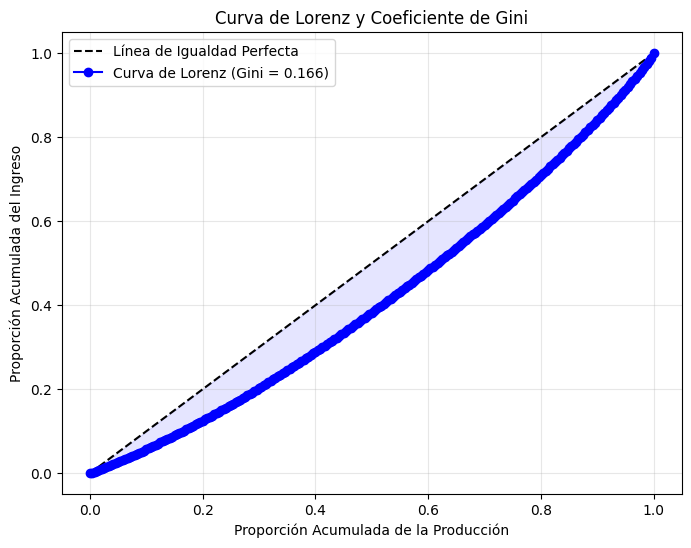

El Coeficiente de Gini calculado es: 0.1664


In [51]:
import numpy as np
import matplotlib.pyplot as plt

def calcular_gini_y_lorenz(ingresos):
    """
    Calcula el coeficiente de Gini y genera los puntos de la Curva de Lorenz.
    Requiere un array de valores absolutos de ingresos o ventas.
    """
    # 1. Validación y ordenamiento de los datos de menor a mayor
    ingresos = np.sort(np.array(ingresos))
    n = len(ingresos)

    # 2. Cálculo de proporciones acumuladas
    # Se inserta un 0 al inicio para anclar la curva en el origen (0,0)
    ingresos_acumulados = np.cumsum(ingresos)
    Y = np.insert(ingresos_acumulados / ingresos_acumulados[-1], 0, 0)
    X = np.insert(np.arange(1, n + 1) / n, 0, 0)

    # 3. Cálculo del Área bajo la Curva de Lorenz (B) usando la regla del trapecio
    area_B = np.trapz(Y, X)

    # 4. Cálculo del Coeficiente de Gini (G = 1 - 2*B)
    # Ya que el área total bajo la línea de igualdad es 0.5, G = (0.5 - B) / 0.5
    gini = 1 - 2 * area_B

    return gini, X, Y

# Datos empíricos de prueba (ej. ingresos de una muestra poblacional o ventas de sucursales)

gini, X_lorenz, Y_lorenz = calcular_gini_y_lorenz(df['Ingresos_CLP'])


# --- Graficación ---
plt.figure(figsize=(8, 6))
# Línea de Igualdad Perfecta
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Línea de Igualdad Perfecta')
# Curva de Lorenz
plt.plot(X_lorenz, Y_lorenz, marker='o', color='blue', label=f'Curva de Lorenz (Gini = {gini:.3f})')

plt.title('Curva de Lorenz y Coeficiente de Gini')
plt.xlabel('Proporción Acumulada de la Producción')
plt.ylabel('Proporción Acumulada del Ingreso')
plt.legend()
plt.grid(True, alpha=0.3)
plt.fill_between(X_lorenz, X_lorenz, Y_lorenz, color='blue', alpha=0.1, label='Área de Desigualdad (A)')
plt.show()

print(f"El Coeficiente de Gini calculado es: {gini:.4f}")

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# The function calcular_gini_y_lorenz was defined in cell qIC8nX7iFYJg
# Assuming df is loaded and available from previous cells

# List of variables to analyze
variables_to_analyze = ['Ingresos_CLP', 'Margen_CLP', 'Ton_Producidas']

# --- Create widgets ---
# Get unique values for 'Centro_Cultivo' and 'Mes'
centros = ['Todos'] + sorted(df['Centro_Cultivo'].unique().tolist())
# Get months in chronological order using 'Orden_Mes'
meses_ordenados = df[['Mes', 'Orden_Mes']].drop_duplicates().sort_values('Orden_Mes')['Mes'].tolist()
meses = ['Todos'] + meses_ordenados

centro_selector = widgets.Dropdown(
    options=centros,
    value='Todos',
    description='Centro de Cultivo:'
)

mes_selector = widgets.Dropdown(
    options=meses,
    value='Todos',
    description='Mes:'
)

# --- Define the plotting function ---
def plot_lorenz_curves(selected_centro, selected_mes):
    clear_output(wait=True) # Clear previous plot before drawing new one

    filtered_df = df.copy()

    if selected_centro != 'Todos':
        filtered_df = filtered_df[filtered_df['Centro_Cultivo'] == selected_centro]

    if selected_mes != 'Todos':
        filtered_df = filtered_df[filtered_df['Mes'] == selected_mes]

    if filtered_df.empty or any(filtered_df[var].isnull().all() for var in variables_to_analyze):
        print("No hay datos suficientes para la selección actual o todas las variables son nulas.")
        return

    fig, axes = plt.subplots(1, len(variables_to_analyze), figsize=(6 * len(variables_to_analyze), 6))

    if len(variables_to_analyze) == 1:
        axes = [axes] # Ensure axes is iterable even for a single plot

    for i, var in enumerate(variables_to_analyze):
        # Only proceed if there are non-null values for the variable
        valid_data = filtered_df[var].dropna()
        n_observations = len(valid_data) # Calculate number of observations

        if valid_data.empty:
            ax = axes[i]
            ax.set_title(f'No hay datos para {var} (N={n_observations})\n({selected_centro}, {selected_mes})')
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.grid(True, alpha=0.3)
            continue

        # Calculate Gini coefficient and Lorenz curve points for the current variable
        gini, X_lorenz, Y_lorenz = calcular_gini_y_lorenz(valid_data)

        # --- Graficación ---
        ax = axes[i]
        # Línea de Igualdad Perfecta
        ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Línea de Igualdad Perfecta')
        # Curva de Lorenz
        ax.plot(X_lorenz, Y_lorenz, marker='o', markersize=2, color='blue', label=f'Curva de Lorenz (Gini = {gini:.3f})')

        ax.set_title(f'Curva de Lorenz y Coeficiente de Gini para {var} (N={n_observations})\n({selected_centro}, {selected_mes})')
        ax.set_xlabel(f'Proporción Acumulada de la Población (por {var})')
        ax.set_ylabel(f'Proporción Acumulada de {var}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.fill_between(X_lorenz, X_lorenz, Y_lorenz, color='blue', alpha=0.1, label='Área de Desigualdad (A)')

    plt.tight_layout()
    plt.show()

# --- Link widgets to the plotting function ---
interactive_plot = widgets.interactive_output(plot_lorenz_curves, {'selected_centro': centro_selector, 'selected_mes': mes_selector})

# --- Display widgets and plot ---
display(widgets.HBox([centro_selector, mes_selector]), interactive_plot)

Output()

Por medio de herramientas de análisis de concentración industrial como el índice de Herfindahl, coeficiente Gini y Curva de Lorenz podemos analizar posibles riesgos operacionales producto de la división de los factores productivos.


---


En terminos generales apreciamos que la organización mantiene resultados
óptimos respecto a como planifica los recursos asignados a sus centros, manteniendo un coeficiente de herfindahl que se mantiene en un rango cercano a 1.900-2.000 que indica baja concentración de las participaciones (siendo 0 competencia perfecta y 10.000 monopolio), o sea que sus centros mantienen actividades casi equivalentes. Lo mismo ocurre si usamos el coeficiente de Gini y la curva de Lorenz para analizar los resultados por transcacion en el periodo de ejercicio, manteniendo una coeficiente inferior a la cifra de 0.20 (siendo 0 igualdad perfecta y 1 concentración extrema), signifcando que las transacciones por venta a cada destino de venta (nacional o exportación) es similar, manteniendo mínima la volatilidad por venta dentro de las proyecciones.


---


Cabe destacar que existen coeficientes de Gini superiores a 0.28 para la distribución del margen de contribución dentro de las transacciones, esto como consecuencia de tener destinos más atractivos en terminos de utilidad como lo son España y Francia que a diferencia del resto mantienen las mejores proporciones de actividad siendo estos los clientes estrella de la miticultora.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# Assuming df is loaded and available from previous cells

# List of variables to analyze
variables_to_analyze = ['Ingresos_CLP', 'Margen_CLP', 'Ton_Producidas']

# --- Create widgets ---
# Get unique values for 'Centro_Cultivo' and 'Mes'
centros = ['Todos'] + sorted(df['Centro_Cultivo'].unique().tolist())
# Get months in chronological order using 'Orden_Mes'
meses_ordenados = df[['Mes', 'Orden_Mes']].drop_duplicates().sort_values('Orden_Mes')['Mes'].tolist()
meses = ['Todos'] + meses_ordenados

centro_selector = widgets.Dropdown(
    options=centros,
    value='Todos',
    description='Centro de Cultivo:'
)

mes_selector = widgets.Dropdown(
    options=meses,
    value='Todos',
    description='Mes:'
)

# --- Define the plotting function ---
def plot_boxplots(selected_centro, selected_mes):
    clear_output(wait=True) # Clear previous plot before drawing new one

    filtered_df = df.copy()

    if selected_centro != 'Todos':
        filtered_df = filtered_df[filtered_df['Centro_Cultivo'] == selected_centro]

    if selected_mes != 'Todos':
        filtered_df = filtered_df[filtered_df['Mes'] == selected_mes]

    if filtered_df.empty:
        print("No hay datos para la selección actual.")
        return

    fig, axes = plt.subplots(1, len(variables_to_analyze), figsize=(6 * len(variables_to_analyze), 6))

    if len(variables_to_analyze) == 1:
        axes = [axes] # Ensure axes is iterable even for a single plot

    for i, var in enumerate(variables_to_analyze):
        ax = axes[i]
        sns.boxplot(y=filtered_df[var], ax=ax, color='skyblue')
        n_observations = len(filtered_df[var].dropna()) # Calculate number of observations
        ax.set_title(f'Distribución de {var} (N={n_observations})\n({selected_centro}, {selected_mes})')
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- Link widgets to the plotting function ---
interactive_plot = widgets.interactive_output(plot_boxplots, {'selected_centro': centro_selector, 'selected_mes': mes_selector})

# --- Display widgets and plot ---
display(widgets.HBox([centro_selector, mes_selector]), interactive_plot)

Output()

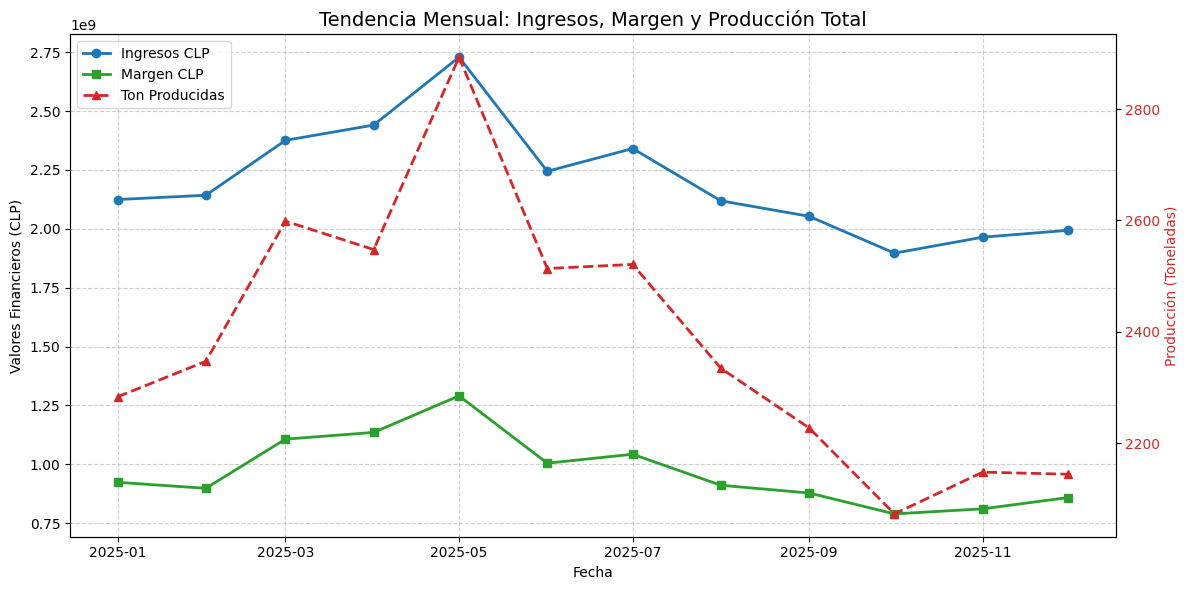

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar datos por mes para la serie de tiempo
df_mensual = df.groupby('Fecha')[['Ingresos_CLP', 'Margen_CLP', 'Ton_Producidas']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Configuración de variables financieras (Eje Izquierdo)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Valores Financieros (CLP)', color='black')
ax1.plot(df_mensual['Fecha'], df_mensual['Ingresos_CLP'], color='tab:blue', label='Ingresos CLP', marker='o', linewidth=2)
ax1.plot(df_mensual['Fecha'], df_mensual['Margen_CLP'], color='tab:green', label='Margen CLP', marker='s', linewidth=2)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.6)

# Configuración de Producción (Eje Derecho)
ax2 = ax1.twinx()
ax2.set_ylabel('Producción (Toneladas)', color='tab:red')
ax2.plot(df_mensual['Fecha'], df_mensual['Ton_Producidas'], color='tab:red', label='Ton Producidas', marker='^', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Título y Leyendas
plt.title('Tendencia Mensual: Ingresos, Margen y Producción Total', fontsize=14)

# Combinar leyendas de ambos ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

fig.tight_layout()
plt.show()

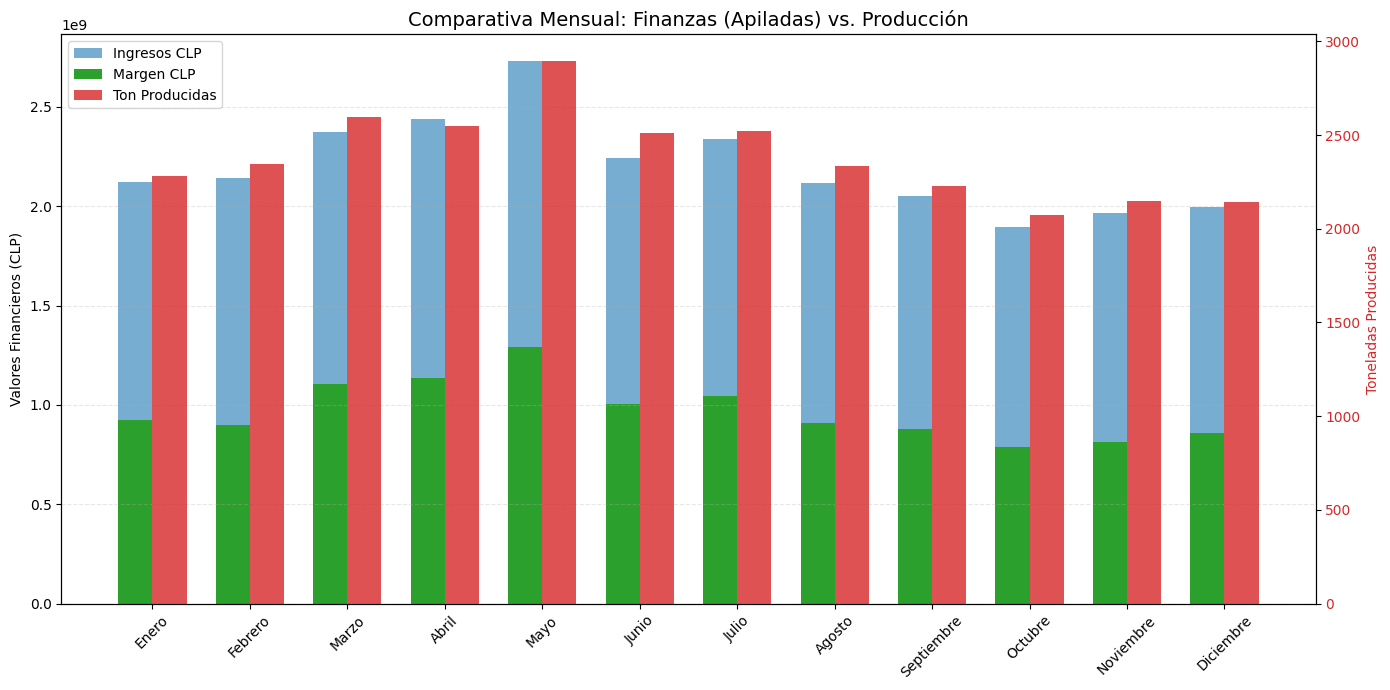

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparar los datos mensuales
df_mensual = df.groupby(['Mes_Num', 'Mes'])[['Ingresos_CLP', 'Margen_CLP', 'Ton_Producidas']].sum().reset_index()
df_mensual = df_mensual.sort_values('Mes_Num')

# Configuración de posiciones para las dos barras por mes
x = np.arange(len(df_mensual))
ancho = 0.35  # Ancho de las barras

fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Primera Barra (Apilada): Ingresos y Margen
# El Margen se dibuja 'dentro' del Ingreso
rects1 = ax1.bar(x - ancho/2, df_mensual['Ingresos_CLP'], ancho, label='Ingresos CLP', color='tab:blue', alpha=0.6)
rects2 = ax1.bar(x - ancho/2, df_mensual['Margen_CLP'], ancho, label='Margen CLP', color='tab:green')

ax1.set_ylabel('Valores Financieros (CLP)')
ax1.set_title('Comparativa Mensual: Finanzas (Apiladas) vs. Producción', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(df_mensual['Mes'], rotation=45)

# 2. Segunda Barra: Toneladas Producidas (Eje derecho)
ax2 = ax1.twinx()
rects3 = ax2.bar(x + ancho/2, df_mensual['Ton_Producidas'], ancho, label='Ton Producidas', color='tab:red', alpha=0.8)
ax2.set_ylabel('Toneladas Producidas', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combinar leyendas
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

ax1.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

Operativamente la empresa es saludable. Mantiene niveles estructurados de ingresos y márgenes que le permiten por su baja volatilidad mantener una buena planificación financiera. Estos niveles de actividad podemos asociarlo a la apropiada diversificación de los factores que posee gracias a la división de sus esfuerzos entre sus centros de cultivo que poseen niveles de actividad similares y la baja concentración de sus mercados objetivos, siendo mínima la diferencia entre los destinos principales con el resultado del destino promedio. Podemos concluir que la empresa sacrifica economías de escala por un menor riesgo operacional, siendo que a pesar de no intensificar sus beneficios al óptimo marginal, logra un buen resultado para el final del ejercicio.

### Análisis de Niveles de Inventario Final

A continuación, se calcula el `Inventario_Final` como la `Ton_Producidas` menos las `Ton_Vendidas`. Se presenta un gráfico de series de tiempo interactivo que muestra el nivel de inventario final a lo largo de los meses, con segmentadores por `Tipo de Producto` y `Centro de Cultivo`.

In [56]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate final inventory levels
df['Inventario_Final'] = df['Ton_Producidas'] - df['Ton_Vendidas']

# --- Create widgets ---
# Get unique values for 'Tipo_Producto' and 'Centro_Cultivo'
productos = ['Todos'] + sorted(df['Tipo_Producto'].unique().tolist())
centros = ['Todos'] + sorted(df['Centro_Cultivo'].unique().tolist())

producto_selector_inv = widgets.Dropdown(
    options=productos,
    value='Todos',
    description='Tipo de Producto:'
)

centro_selector_inv = widgets.Dropdown(
    options=centros,
    value='Todos',
    description='Centro de Cultivo:'
)

# --- Define the plotting function ---
def plot_inventario_final(selected_product, selected_centro):
    clear_output(wait=True) # Clear previous plot before drawing new one

    filtered_df = df.copy()

    if selected_product != 'Todos':
        filtered_df = filtered_df[filtered_df['Tipo_Producto'] == selected_product]

    if selected_centro != 'Todos':
        filtered_df = filtered_df[filtered_df['Centro_Cultivo'] == selected_centro]

    if filtered_df.empty:
        print("No hay datos para la selección actual.")
        return

    # Aggregate Inventario_Final by Fecha (which represents month in this dataset)
    monthly_inventario_final = filtered_df.groupby('Fecha')['Inventario_Final'].sum().reset_index()

    fig = plt.figure(figsize=(12, 6))
    sns.lineplot(x='Fecha', y='Inventario_Final', data=monthly_inventario_final)
    plt.title(f'Niveles de Inventario Final por Mes\n(Producto: {selected_product}, Centro: {selected_centro})')
    plt.xlabel('Fecha')
    plt.ylabel('Inventario Final (Toneladas)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Link widgets to the plotting function ---
interactive_plot_inv = widgets.interactive_output(plot_inventario_final, {
    'selected_product': producto_selector_inv,
    'selected_centro': centro_selector_inv
})

# --- Display widgets and plot ---
display(widgets.VBox([widgets.HBox([producto_selector_inv, centro_selector_inv]), interactive_plot_inv]))

En general mantiene niveles de inventarios eficientes si asumimos un supuesto de venta pactadas previamente bajo instrumentos de cobertura como opciones de compra sobre mitílidos. Como observación encontramos un nivel superior de inventarios de reserva de choritos frescos que de no rotar rápido representarán una pérdida en la oportunidad de marginar, pasando a ser un producto congelado que significa menor riesgo al mediano plazo pero menores beneficios.

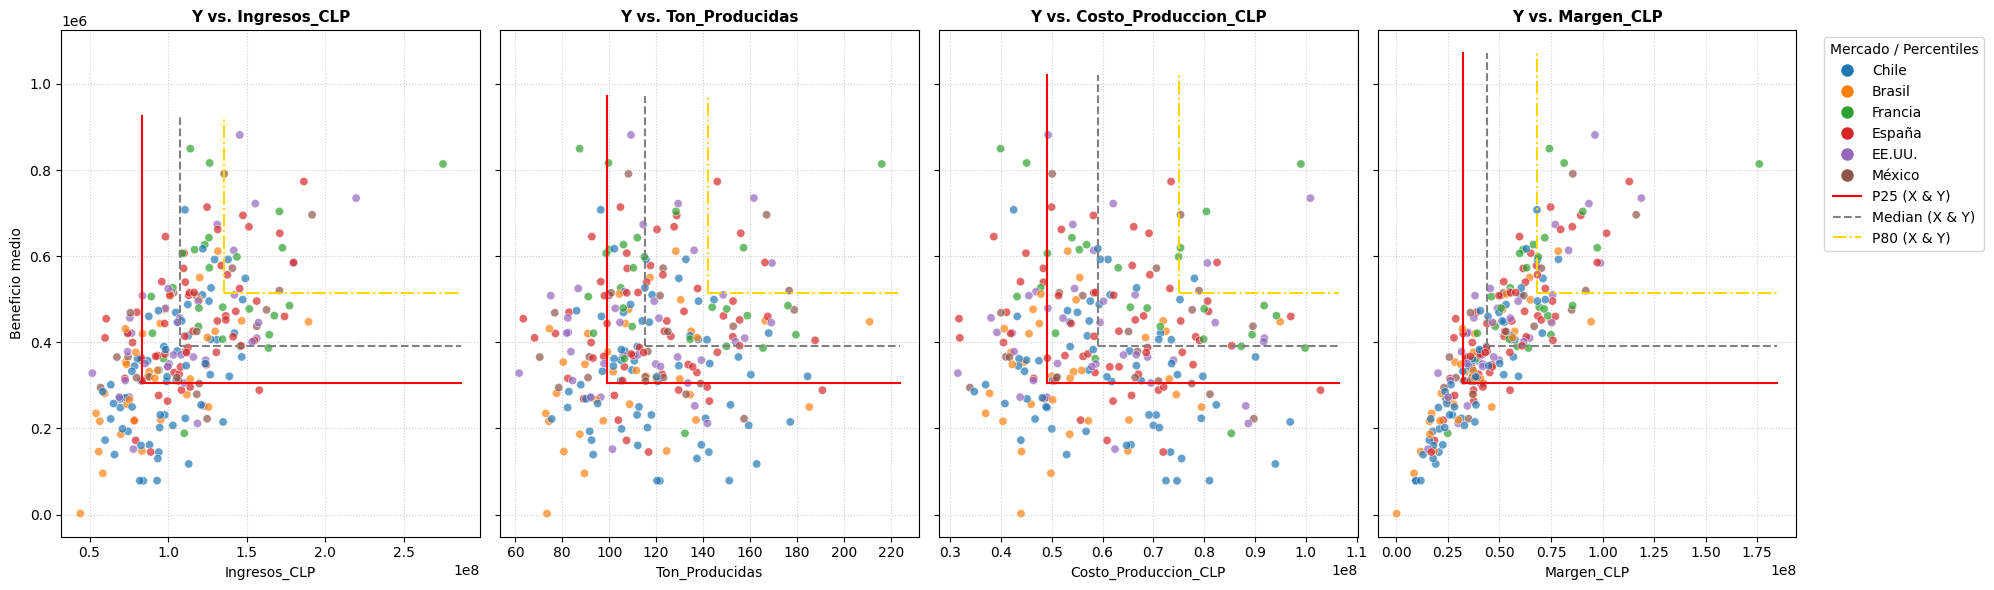

In [57]:
# Define the independent variables and the dependent variable
independent_vars = ['Ingresos_CLP','Ton_Producidas','Costo_Produccion_CLP','Margen_CLP']
dependent_var = 'Beneficio medio'

# Create a dynamically sized subplot grid (1 row, N columns)
fig, axes = plt.subplots(
    nrows=1, ncols=len(independent_vars), figsize=(20, 6), sharey=True
)

# Get unique 'Mercado' categories and their colors for consistent plotting and legend
hue_categories = df['Mercado'].unique()
# Use a color palette to get distinct colors for hue categories
palette = sns.color_palette('tab10', n_colors=len(hue_categories)) # Use tab10 for distinct colors
hue_colors = {cat: palette[j] for j, cat in enumerate(hue_categories)}

for i, var in enumerate(independent_vars):
    sns.scatterplot(
        data=df,
        x=var,
        y=dependent_var,
        ax=axes[i],
        hue='Mercado', # Add color based on 'Mercado'
        palette=hue_colors, # Use the defined palette for consistency
        alpha=0.7,
        edgecolor="w",
        legend=False # Disable seaborn's automatic legend
    )

    # Get current axis limits (after scatterplot might have autoscaled)
    x_min, x_max = axes[i].get_xlim()
    y_min, y_max = axes[i].get_ylim()

    # Calculate percentiles for current independent variable (x-axis)
    median_x = df[var].median()
    pv80 = np.percentile(df[var], 80)
    pv25 = np.percentile(df[var], 25)

    # Calculate percentiles for dependent variable (y-axis)
    median_y = np.percentile(df[dependent_var], 50)
    p80 = np.percentile(df[dependent_var], 80)
    p25 = np.percentile(df[dependent_var], 25)

    # Draw vertical lines (from percentile intersection point upwards)
    # P25 lines (red, solid)
    axes[i].plot([pv25, pv25], [p25, y_max], color='red', linestyle='-', linewidth=1.5)
    # Median lines (gray, dashed)
    axes[i].plot([median_x, median_x], [median_y, y_max], color='gray', linestyle='--', linewidth=1.5)
    # P80 lines (gold, dash-dot)
    axes[i].plot([pv80, pv80], [p80, y_max], color='gold', linestyle='-.', linewidth=1.5)

    # Draw horizontal lines (from percentile intersection point rightwards)
    # P25 lines (red, solid)
    axes[i].plot([pv25, x_max], [p25, p25], color='red', linestyle='-', linewidth=1.5)
    # Median lines (gray, dashed) - matched with vertical median color and linestyle
    axes[i].plot([median_x, x_max], [median_y, median_y], color='gray', linestyle='--', linewidth=1.5)
    # P80 lines (gold, dash-dot)
    axes[i].plot([pv80, x_max], [p80, p80], color='gold', linestyle='-.', linewidth=1.5)

    axes[i].set_title(f"Y vs. {var}", fontsize=11, weight="semibold")
    axes[i].grid(True, linestyle=":", alpha=0.6)

    # Create custom legend for the last subplot
    if i == len(independent_vars) - 1:
        from matplotlib.lines import Line2D
        legend_handles = []
        legend_labels = []

        # Add handles for 'Mercado' categories
        for cat, color in hue_colors.items():
            legend_handles.append(Line2D([0], [0], marker='o', color='w', label=cat,
                                          markerfacecolor=color, markersize=10))
            legend_labels.append(cat)

        # Add handles for percentile lines (grouped for brevity)
        legend_handles.append(Line2D([0], [0], color='red', linestyle='-', linewidth=1.5))
        legend_labels.append('P25 (X & Y)')

        legend_handles.append(Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5))
        legend_labels.append('Median (X & Y)')

        legend_handles.append(Line2D([0], [0], color='gold', linestyle='-.', linewidth=1.5))
        legend_labels.append('P80 (X & Y)')

        axes[i].legend(handles=legend_handles, labels=legend_labels,
                       title='Mercado / Percentiles', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        # Ensure no legend is shown for other subplots
        pass

plt.tight_layout()
plt.show()

# **Análisis y sistema de Control de Gestión**
En esta sección exploraremos un sistema de alarma y monitoreo de la gestión al corto, mediano y largo plazo guardando relación con las oportunidades de mejora y riesgos latentes de la organización alineandolos con los objetivos del BSC y custodiado por un sistema de palancas de Simon's.

**Cierre mensual**

In [58]:
import pandas as pd
import numpy as np
from itables import show

# Lógica adaptada del script de scoring externo
def aplicar_sistema_scoring(dataframe):
    temp_df = dataframe.copy()

    # Definición de pesos según el sistema de scoring compuesto
    pesos = {
        'Margen_%': 0.40,
        'Cumplimiento_Venta_%': 0.30,
        'Mortalidad_%': 0.20,
        'Tasa_Rechazo_x_Ton': 0.10
    }

    # Funciones de normalización Min-Max (0-1)
    def norm_pos(col):
        return (col - col.min()) / (col.max() - col.min())

    def norm_neg(col):
        return (col.max() - col) / (col.max() - col.min())

    # Aplicar normalización (Variables negativas se invierten: menor valor = mayor puntaje)
    s_margen = norm_pos(temp_df['Margen_%'])
    s_cumplimiento = norm_pos(temp_df['Cumplimiento_Venta_%'])
    s_mortalidad = norm_neg(temp_df['Mortalidad_%'])
    s_rechazo = norm_neg(temp_df['Tasa_Rechazo_x_Ton'])

    # Cálculo del Score Compuesto (Escala 0-100)
    temp_df['Score_Final'] = (
        (s_margen * pesos['Margen_%']) +
        (s_cumplimiento * pesos['Cumplimiento_Venta_%']) +
        (s_mortalidad * pesos['Mortalidad_%']) +
        (s_rechazo * pesos['Tasa_Rechazo_x_Ton'])
    ) * 100

    # Categorización del desempeño
    condiciones = [
        (temp_df['Score_Final'] >= 80),
        (temp_df['Score_Final'] >= 50) & (temp_df['Score_Final'] < 80),
        (temp_df['Score_Final'] < 50)
    ]
    categorias = ['Excelente', 'Regular', 'Crítico']
    temp_df['Evaluacion_Scoring'] = np.select(condiciones, categorias, default='N/A')

    return temp_df

# Ejecutar el scoring sobre el dataframe principal
df = aplicar_sistema_scoring(df)

print("Sistema de scoring aplicado exitosamente a todos los registros.")
show(df[['Fecha', 'Centro_Cultivo', 'Tipo_Producto', 'Score_Final', 'Evaluacion_Scoring']].sort_values(by='Score_Final', ascending=False))

Sistema de scoring aplicado exitosamente a todos los registros.


Loading ITables v2.8.0 from the internet... (need help?)


In [59]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# Prepare unique values for selectors
meses = sorted(df['Mes'].unique().tolist(), key=lambda x: df[df['Mes'] == x]['Orden_Mes'].iloc[0])
centros = sorted(df['Centro_Cultivo'].unique().tolist())
productos = sorted(df['Tipo_Producto'].unique().tolist())
mercados = sorted(df['Mercado'].unique().tolist())

# Create SelectMultiple widgets for the 'casillas' (checkbox menu) style
sel_mes = widgets.SelectMultiple(options=meses, value=meses, description='Meses', rows=6)
sel_centro = widgets.SelectMultiple(options=centros, value=centros, description='Centros', rows=6)
sel_producto = widgets.SelectMultiple(options=productos, value=productos, description='Productos', rows=4)
sel_mercado = widgets.SelectMultiple(options=mercados, value=mercados, description='Mercados', rows=6)

# Output container
output_score_panel = widgets.Output()

def update_score_display(change):
    with output_score_panel:
        clear_output(wait=True)

        # Apply filters
        filtered_data = df[
            (df['Mes'].isin(sel_mes.value)) &
            (df['Centro_Cultivo'].isin(sel_centro.value)) &
            (df['Tipo_Producto'].isin(sel_producto.value)) &
            (df['Mercado'].isin(sel_mercado.value))
        ]

        if filtered_data.empty:
            print("No hay datos para la selección actual.")
            return

        mean_score = filtered_data['Score_Final'].mean()
        count_regs = len(filtered_data)

        # Style and logic for the visual card
        color = "#28a745" if mean_score >= 80 else ("#ffc107" if mean_score >= 50 else "#dc3545")
        status = "Excelente" if mean_score >= 80 else ("Regular" if mean_score >= 50 else "Crítico")

        card_html = f"""
        <div style="padding: 15px; border-radius: 10px; background-color: #f0f2f6; border-left: 8px solid {color};">
            <h3 style='margin-top:0;'>Promedio del Scoring Seleccionado</h3>
            <span style='font-size: 32px; font-weight: bold; color: {color};'>{mean_score:.2f}</span>
            <p>Estado General: <b>{status}</b> | Registros analizados: {count_regs}</p>
        </div>
        """
        display(widgets.HTML(card_html))

        # Display top records for detail
        print("\nDetalle de los registros con mayor puntaje:")
        display(filtered_data[['Fecha', 'Centro_Cultivo', 'Mercado', 'Score_Final', 'Evaluacion_Scoring']]
                .sort_values('Score_Final', ascending=False).head(5))

# Observe changes
for widget in [sel_mes, sel_centro, sel_producto, sel_mercado]:
    widget.observe(update_score_display, names='value')

# Layout organization
controls = widgets.VBox([
    widgets.HTML("<b>Filtros (Usa Ctrl/Cmd + click para seleccionar varios):</b>"),
    widgets.HBox([sel_mes, sel_centro]),
    widgets.HBox([sel_producto, sel_mercado])
])

display(widgets.VBox([controls, output_score_panel]))
update_score_display(None) # Initial trigger

In [60]:
import pandas as pd
import numpy as np
from itables import show

def sistema_scoring_monitoreo(dataframe):
    temp_df = dataframe.copy()

    # Definición de pesos solicitados
    pesos = {
        'Mortalidad_%': 0.45,
        'Rechazos_Calidad': 0.25,
        'Ton_No_Vendidas': 0.30
    }

    # Función de normalización inversa (Menor riesgo = Mejor puntaje)
    def norm_riesgo(col):
        if col.max() == col.min(): return 1.0
        return (col.max() - col) / (col.max() - col.min())

    # Aplicar normalización a las variables de riesgo
    s_mortalidad = norm_riesgo(temp_df['Mortalidad_%'])
    s_rechazos = norm_riesgo(temp_df['Rechazos_Calidad'])
    s_no_vendidas = norm_riesgo(temp_df['Ton_No_Vendidas'])

    # Cálculo del Score de Monitoreo (0-100)
    temp_df['Score_Monitoreo'] = (
        (s_mortalidad * pesos['Mortalidad_%']) +
        (s_rechazos * pesos['Rechazos_Calidad']) +
        (s_no_vendidas * pesos['Ton_No_Vendidas'])
    ) * 100

    # Categorización según nivel de riesgo
    # > 80: Estable | 50-80: Monitoreo | < 50: Revisión inmediata
    condiciones = [
        (temp_df['Score_Monitoreo'] >= 80),
        (temp_df['Score_Monitoreo'] >= 50) & (temp_df['Score_Monitoreo'] < 80),
        (temp_df['Score_Monitoreo'] < 50)
    ]
    niveles = ['Estable', 'Monitoreo', 'Revisión inmediata']
    temp_df['Nivel_Monitoreo'] = np.select(condiciones, niveles, default='Revisión inmediata')

    return temp_df

# Aplicar al dataframe principal
df = sistema_scoring_monitoreo(df)

print("Sistema de Scoring de Monitoreo generado exitosamente.")
# Mostrar resumen ordenado por mayor riesgo (menor puntaje) incluyendo Tipo_Producto y Mercado
resumen_monitoreo = df[['Fecha', 'Centro_Cultivo', 'Tipo_Producto', 'Mercado', 'Mortalidad_%', 'Rechazos_Calidad', 'Ton_No_Vendidas', 'Score_Monitoreo', 'Nivel_Monitoreo']]
show(resumen_monitoreo.sort_values(by='Score_Monitoreo'))

Sistema de Scoring de Monitoreo generado exitosamente.


Loading ITables v2.8.0 from the internet... (need help?)


In [61]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Estandarización de variables clave
variables_a_estandarizar = ['Margen_%', 'Cumplimiento_Venta_%', 'Mortalidad_%', 'Tasa_Rechazo_x_Ton']

# Crear copia de trabajo
df_dashboard = df.copy()
scaler = StandardScaler()

# Llenar valores nulos con la media para evitar errores en el escalado
for col in variables_a_estandarizar:
    df_dashboard[col] = df_dashboard[col].fillna(df_dashboard[col].mean())

df_dashboard[variables_a_estandarizar] = scaler.fit_transform(df_dashboard[variables_a_estandarizar])

# Renombrar columnas escaladas
columnas_escaladas = [f'{var}_scaled' for var in variables_a_estandarizar]
df_dashboard.rename(columns=dict(zip(variables_a_estandarizar, columnas_escaladas)), inplace=True)

# Preparar dimensiones temporales
df_dashboard['Fecha'] = pd.to_datetime(df_dashboard['Fecha'])
df_dashboard['Semana'] = df_dashboard['Fecha'].dt.isocalendar().week.astype(int)

# Escala: Queremos que +/- 3 desviaciones estándar equivalgan a +/- 100 puntos
FACTOR_ESCALA = 100 / 3.0

# --- Configuración de Widgets ---
centros = ['Todos'] + sorted(df_dashboard['Centro_Cultivo'].unique().tolist())
productos = ['Todos'] + sorted(df_dashboard['Tipo_Producto'].unique().tolist())
meses_lista = ['Todos'] + df_dashboard[['Mes', 'Orden_Mes']].drop_duplicates().sort_values('Orden_Mes')['Mes'].tolist()
semanas = ['Todos'] + sorted(df_dashboard['Semana'].unique().tolist())

sel_centro = widgets.Dropdown(options=centros, value='Todos', description='Centro:')
sel_producto = widgets.Dropdown(options=productos, value='Todos', description='Producto:')
sel_mes = widgets.Dropdown(options=meses_lista, value='Todos', description='Mes:')
sel_semana = widgets.Dropdown(options=semanas, value='Todos', description='Semana:')

def actualizar_dashboard(m, s, c, p):
    clear_output(wait=True)
    f_df = df_dashboard.copy()

    if m != 'Todos': f_df = f_df[f_df['Mes'] == m]
    if s != 'Todos': f_df = f_df[f_df['Semana'] == s]
    if c != 'Todos': f_df = f_df[f_df['Centro_Cultivo'] == c]
    if p != 'Todos': f_df = f_df[f_df['Tipo_Producto'] == p]

    if f_df.empty:
        display(widgets.HTML('<b>No se encontraron datos para los filtros seleccionados.</b>'))
        return

    indicadores = []
    for var in columnas_escaladas:
        nombre_etiqueta = var.replace('_scaled', '').replace('_', ' ')
        valor_z = f_df[var].mean()

        # Mapeo a escala -100 a 100
        puntaje = max(min(valor_z * FACTOR_ESCALA, 100), -100)

        # Lógica de colores solicitada: Negativo = Rojo (danger), Positivo = Verde (success)
        estilo = 'success' if puntaje >= 0 else 'danger'

        barra = widgets.FloatProgress(value=puntaje, min=-100, max=100, bar_style=estilo, layout={'width': '65%'})
        etiqueta_valor = widgets.Label(value=f'{puntaje:.1f} pts', layout={'width': '15%'})

        fila = widgets.HBox([
            widgets.Label(value=f'{nombre_etiqueta}:', layout={'width': '20%'}),
            barra,
            etiqueta_valor
        ])
        indicadores.append(fila)

    display(widgets.VBox([
        widgets.HTML('<h3>Panel de Control de Gestión: Desempeño Relativo</h3>'),
        widgets.HTML('<p><i>Escala de -100 a 100 (0 = Promedio Histórico). Rojo: < 0 | Verde: > 0</i></p>'),
        widgets.VBox(indicadores)
    ]))

out = widgets.interactive_output(actualizar_dashboard, {'m': sel_mes, 's': sel_semana, 'c': sel_centro, 'p': sel_producto})

ui = widgets.VBox([
    widgets.HBox([sel_mes, sel_semana]),
    widgets.HBox([sel_centro, sel_producto]),
    out
])
display(ui)

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from sklearn.preprocessing import StandardScaler
from IPython.display import display, clear_output
import numpy as np

# 1. Función de agregación y preparación por dimensión
def preparar_data_dimension(dataframe, dimension):
    # Agrupamos por la dimensión seleccionada para comparar promedios de desempeño
    grouped = dataframe.groupby(dimension).agg({
        'Cumplimiento_Venta_%': 'mean',
        'Mortalidad_%': 'mean',
        'Tasa_Rechazo_x_Ton': 'mean',
        'Margen_%': 'mean',
        'Ton_Producidas': 'sum'
    }).reset_index()

    scaler = StandardScaler()

    # Normalización para Score Gestión (0-100)
    def norm_pos(col): return (col - col.min()) / (col.max() - col.min()) if (col.max() - col.min()) != 0 else col * 0
    def norm_neg(col): return (col.max() - col) / (col.max() - col.min()) if (col.max() - col.min()) != 0 else col * 0

    s_cumplimiento = norm_pos(grouped['Cumplimiento_Venta_%'])
    s_mortalidad = norm_neg(grouped['Mortalidad_%'])
    s_rechazo = norm_neg(grouped['Tasa_Rechazo_x_Ton'])

    # Eje X: Score de Gestión (Compuesto) | Eje Y: Margen Relativo (Z-Score)
    grouped['Score_X'] = (s_cumplimiento * 0.50 + s_mortalidad * 0.35 + s_rechazo * 0.15) * 100
    grouped['Margen_Z'] = scaler.fit_transform(grouped[['Margen_%']])

    return grouped

# --- Widgets: Selectores de Dimensión Visual ---
sel_dimension = widgets.ToggleButtons(
    options=[('Centros', 'Centro_Cultivo'), ('Productos', 'Tipo_Producto'), ('Mercados', 'Mercado')],
    value='Centro_Cultivo',
    description='Analizar por:',
    button_style='info',
    tooltips=['Comparar Centros de Cultivo', 'Comparar Tipos de Producto', 'Comparar Mercados de Destino'],
)

output_static = widgets.Output()

def update_dimension_plot(dimension):
    with output_static:
        clear_output(wait=True)

        plot_df = preparar_data_dimension(df, dimension)

        plt.figure(figsize=(12, 8))

        # Definir límites visuales para cuadrantes
        y_min, y_max = plot_df['Margen_Z'].min() - 1, plot_df['Margen_Z'].max() + 1

        # Sombreado de Cuadrantes
        plt.axvspan(50, 105, ymin=0.5, ymax=1, color='green', alpha=0.05)
        plt.axvspan(-5, 50, ymin=0, ymax=0.5, color='red', alpha=0.05)

        # Scatterplot: Tamaño por volumen total, Color por Categoría
        sns.scatterplot(
            data=plot_df, x='Score_X', y='Margen_Z',
            size='Ton_Producidas', hue=dimension,
            palette='viridis', sizes=(100, 1200), alpha=0.8
        )

        # Etiquetas directas para identificar cada punto
        for i in range(plot_df.shape[0]):
            plt.text(plot_df.Score_X[i]+1.5, plot_df.Margen_Z[i],
                     plot_df[dimension][i], fontsize=10, fontweight='bold')

        # Líneas de ejes
        plt.axhline(0, color='black', linestyle='-', linewidth=1.5)
        plt.axvline(50, color='black', linestyle='-', linewidth=1.5)

        # Nombres de Cuadrantes
        plt.text(75, y_max*0.9, 'ESTRELLAS', fontsize=12, fontweight='bold', color='green', alpha=0.4, ha='center')
        plt.text(25, y_max*0.9, 'RETOS', fontsize=12, fontweight='bold', color='orange', alpha=0.4, ha='center')
        plt.text(75, y_min*0.9, 'EFICIENCIA', fontsize=12, fontweight='bold', color='blue', alpha=0.4, ha='center')
        plt.text(25, y_min*0.9, 'FOCO CRÍTICO', fontsize=12, fontweight='bold', color='red', alpha=0.4, ha='center')

        plt.title(f'Matriz de Desempeño: Comparativa por {dimension.replace("_", " ")}', fontsize=14)
        plt.xlabel('Score de Gestión (0-100)')
        plt.ylabel('Margen % (Normalizado Z-Score)')
        plt.xlim(-5, 105)
        plt.ylim(y_min, y_max)
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Categorías')

        plt.show()

# Layout de la Interfaz
widgets.interactive_output(update_dimension_plot, {'dimension': sel_dimension})
display(widgets.VBox([sel_dimension, output_static]))

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

def generar_sistema_semaforos(dataframe):
    df_risk = dataframe.copy()

    def norm_robust(col, inverse=False):
        mediana = col.median()
        mad = (col - mediana).abs().median()
        if mad == 0: return col * 0 + 0.5
        z_robust = 0.6745 * (col - mediana) / mad
        norm = (z_robust - z_robust.min()) / (z_robust.max() - z_robust.min())
        return 1 - norm if inverse else norm

    df_risk['Score_Sanitario_Raw'] = norm_robust(df_risk['Mortalidad_%'], inverse=True) * 100
    df_risk['Score_Calidad'] = norm_robust(df_risk['Tasa_Rechazo_x_Ton'], inverse=True) * 100

    s_precio = norm_robust(df_risk['Precio_Ton_CLP'])
    s_cumplimiento = norm_robust(df_risk['Cumplimiento_Venta_%'])
    df_risk['Score_Comercial'] = (s_precio * 0.60 + s_cumplimiento * 0.40) * 100

    df_risk['Score_Financiero_Raw'] = norm_robust(df_risk['Margen_%']) * 100

    map_penalizacion = {'Normal': 0.20, 'Alerta': 0.30, 'Crítico': 0.50}
    df_risk['Factor_Penalizacion'] = df_risk['Estado_Operacion'].map(map_penalizacion).fillna(0.20)
    df_risk['Score_Operacional'] = ((df_risk['Score_Sanitario_Raw'] + df_risk['Score_Calidad']) / 2) * (1 - df_risk['Factor_Penalizacion'])

    return df_risk

df_final = generar_sistema_semaforos(df)
output_dashboard = widgets.Output()

def get_color_gradient(score, cmap_name='RdYlGn'):
    cmap = plt.get_cmap(cmap_name)
    return mcolors.to_hex(cmap(score / 100))

def get_gold_gradient(score):
    return f"rgba(212, 175, 55, {max(0.3, score / 100)})"

def render_dashboard(centros_sel, productos_sel):
    with output_dashboard:
        clear_output()
        filtered_df = df_final.copy()

        if 'Ninguno' not in centros_sel: filtered_df = filtered_df[filtered_df['Centro_Cultivo'].isin(centros_sel)]
        if 'Ninguno' not in productos_sel: filtered_df = filtered_df[filtered_df['Tipo_Producto'].isin(productos_sel)]

        if filtered_df.empty:
            display(HTML("<div style='color: gray; text-align: center; padding: 20px;'>Sin datos para la selección.</div>"))
            return

        resumen = {
            'Sanitario': filtered_df['Score_Sanitario_Raw'].mean(),
            'Calidad': filtered_df['Score_Calidad'].mean(),
            'Comercial': filtered_df['Score_Comercial'].mean(),
            'Financiero': filtered_df['Score_Financiero_Raw'].mean(),
            'Operacional': filtered_df['Score_Operacional'].mean()
        }

        promedio_global = (resumen['Sanitario'] + resumen['Calidad'] + resumen['Comercial'] + resumen['Financiero']) / 4

        html_dashboard = f"""
        <div style='background-color: #121212; padding: 30px; border-radius: 12px; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto; color: #e0e0e0;'>
            <div style='display: flex; justify-content: space-between; align-items: baseline; border-bottom: 1px solid #333; padding-bottom: 15px; margin-bottom: 25px;'>
                <span style='font-size: 0.8em; letter-spacing: 2px; color: #888;'>MONITOREO DE RIESGO ESTRATÉGICO</span>
                <div style='text-align: right;'>
                    <span style='font-size: 0.8em; color: #888; margin-right: 10px;'>PUNTUACIÓN GLOBAL</span>
                    <span style='font-size: 1.5em; font-weight: 300; color: {get_color_gradient(promedio_global)};'>{promedio_global:.1f}</span>
                </div>
            </div>

            <div style='display: flex; justify-content: space-between; align-items: center;'>
                <div style='text-align: center; flex: 1;'>
                    <div style='width: 12px; height: 12px; border-radius: 50%; background: {get_color_gradient(resumen['Sanitario'])}; margin: 0 auto 10px;'></div>
                    <div style='font-size: 1.2em; font-weight: 500;'>{resumen['Sanitario']:.1f}</div>
                    <div style='font-size: 0.7em; color: #888; text-transform: uppercase;'>Prom. Sanitario</div>
                </div>
                <div style='text-align: center; flex: 1;'>
                    <div style='width: 12px; height: 12px; border-radius: 50%; background: {get_color_gradient(resumen['Calidad'])}; margin: 0 auto 10px;'></div>
                    <div style='font-size: 1.2em; font-weight: 500;'>{resumen['Calidad']:.1f}</div>
                    <div style='font-size: 0.7em; color: #888; text-transform: uppercase;'>Prom. Calidad</div>
                </div>
                <div style='text-align: center; flex: 1;'>
                    <div style='width: 12px; height: 12px; border-radius: 50%; background: gold; opacity: 0.8; margin: 0 auto 10px;'></div>
                    <div style='font-size: 1.2em; font-weight: 500;'>{resumen['Comercial']:.1f}</div>
                    <div style='font-size: 0.7em; color: #888; text-transform: uppercase;'>Prom. Comercial</div>
                </div>
                <div style='text-align: center; flex: 1;'>
                    <div style='width: 12px; height: 12px; border-radius: 50%; background: {get_color_gradient(resumen['Financiero'])}; margin: 0 auto 10px;'></div>
                    <div style='font-size: 1.2em; font-weight: 500;'>{resumen['Financiero']:.1f}</div>
                    <div style='font-size: 0.7em; color: #888; text-transform: uppercase;'>Prom. Financiero</div>
                </div>
                <div style='text-align: center; flex: 1.5; border-left: 1px solid #333;'>
                    <div style='font-size: 2em; font-weight: 700; color: {get_color_gradient(resumen['Operacional'])};'>{resumen['Operacional']:.1f}</div>
                    <div style='font-size: 0.8em; font-weight: bold; color: white;'>OPERACIONAL</div>
                </div>
            </div>
        </div>
        """
        display(HTML(html_dashboard))
        print("\nAlertas de Criticidad Operacional (Top 5):")
        display(filtered_df[['Centro_Cultivo', 'Tipo_Producto', 'Score_Operacional']].sort_values('Score_Operacional').head(5))

opts_centros = sorted(df_final['Centro_Cultivo'].unique().tolist())
opts_productos = sorted(df_final['Tipo_Producto'].unique().tolist())

list_centros = widgets.SelectMultiple(options=opts_centros, value=opts_centros, description='Centros', layout={'width': '45%'}, rows=6)
list_productos = widgets.SelectMultiple(options=opts_productos, value=opts_productos, description='Productos', layout={'width': '45%'}, rows=6)

interactive_out = widgets.interactive_output(render_dashboard, {'centros_sel': list_centros, 'productos_sel': list_productos})
display(widgets.HBox([list_centros, list_productos], layout={'margin': '10px 0'}), output_dashboard)

Output()